# 1. Thư viện và dữ liệu

In [43]:
# Import các thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Iterator, Optional, Dict, Callable
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
warnings.filterwarnings('ignore')
from prophet import Prophet
from datetime import datetime
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [44]:
df_emdat = pd.read_excel('../data/emdat_disaster.xlsx')
df_emdat.head()

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2018-0040-BRA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),DFO:4576,NaN,BRA,...,NaN,NaN,NaN,10000.0,12492.0,80.049596,"[{""adm2_code"":9961,""adm2_name"":""Rio De Janeiro""}]","[{""gid_2"":""BRA.19.68_2"",""migration_date"":""2025...",2018-02-20,2025-12-20
1,2002-0351-USA,No,nat-cli-wil-for,Natural,Climatological,Wildfire,Forest fire,NaN,NaN,USA,...,NaN,NaN,NaN,20000.0,34879.0,57.341840,"[{""adm1_code"":3219,""adm1_name"":""Colorado""}]","[{""gid_1"":""USA.6_1"",""migration_date"":""2025-12-...",2003-07-01,2025-12-20
2,2022-0770-RWA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,RWA,...,NaN,NaN,NaN,NaN,NaN,93.294607,"[{""adm1_code"":21970,""adm1_name"":""Kigali City/U...","[{""gid_1"":""RWA.5_1"",""migration_date"":""2025-12-...",2022-11-25,2025-12-20
3,2024-9796-USA,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,USA,...,NaN,NaN,NaN,5400000.0,5400000.0,100.000000,NaN,"[{""gid_1"":""USA.13_1"",""name_1"":""Idaho""},{""gid_1...",2024-10-29,2025-12-20
4,2022-0563-IDN,No,tec-tra-roa-roa,Technological,Transport,Road,Road,NaN,NaN,IDN,...,NaN,NaN,NaN,NaN,NaN,93.294607,NaN,NaN,2022-09-01,2023-09-26


In [45]:
df_population = pd.read_csv('../data/wb_population.csv')
df_population.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,107906,108727,108735,108908,109203,108587,107700,107310,107359,107995
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,607123269,623369401,640058741,657801085,675950189,694446100,713090928,731821393,750491370,769280888
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,33831764,34700612,35688935,36743039,37856121,39068979,40000412,40578842,41454761,42647492
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,418127845,429454743,440882906,452195915,463365429,474569351,485920997,497387180,509398589,521764076
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,28157798,29183070,30234839,31297155,32375632,33451132,34532429,35635029,36749906,37885849


# 2. Khám phá dữ liệu sơ bộ

## 2.1. Kiểm tra thông tin cơ bản về dữ liệu

In [46]:
print(df_emdat.shape)
df_emdat.info()
df_emdat.describe()

(16631, 47)
<class 'pandas.DataFrame'>
RangeIndex: 16631 entries, 0 to 16630
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     16631 non-null  str    
 1   Historic                                   16631 non-null  str    
 2   Classification Key                         16631 non-null  str    
 3   Disaster Group                             16631 non-null  str    
 4   Disaster Subgroup                          16631 non-null  str    
 5   Disaster Type                              16631 non-null  str    
 6   Disaster Subtype                           16631 non-null  str    
 7   External IDs                               4291 non-null   str    
 8   Event Name                                 5255 non-null   str    
 9   ISO                                        16631 non-null  str    
 10  Country              

,AID Contribution ('000 US$),Magnitude,Latitude,Longitude,Start Year,Start Month,Start Day,End Year,End Month,End Day,...,No. Affected,No. Homeless,Total Affected,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI
count,4.890000e+02,3.370000e+03,1844.000000,1844.000000,16631.000000,16556.000000,15049.000000,16631.000000,16463.000000,15133.000000,...,7.743000e+03,1.350000e+03,1.242800e+04,3.400000e+01,3.300000e+01,7.200000e+02,7.120000e+02,3.272000e+03,3.236000e+03,16153.000000
mean,2.855916e+04,5.954269e+04,16.649881,42.457874,2011.451867,6.491000,15.340222,2011.483074,6.626435,15.865261,...,6.203806e+05,3.127961e+04,3.905640e+05,5.711168e+06,6.544622e+06,1.407522e+06,1.795895e+06,1.185778e+06,1.538351e+06,71.880172
std,2.118956e+05,7.421045e+05,21.855883,75.572546,7.627329,3.397919,8.976045,7.629795,3.376261,8.905703,...,6.550484e+06,2.130254e+05,5.180447e+06,1.718642e+07,1.812265e+07,4.844269e+06,6.141822e+06,6.295747e+06,8.483588e+06,12.346403
min,3.000000e+00,-5.700000e+01,-72.640000,-172.095000,2000.000000,1.000000,1.000000,2000.000000,1.000000,1.000000,...,1.000000e+00,3.000000e+00,1.000000e+00,8.400000e+01,1.350000e+02,3.400000e+01,4.900000e+01,2.000000e+00,3.000000e+00,54.895152
25%,1.660000e+02,1.222500e+01,1.205750,1.456750,2005.000000,4.000000,7.000000,2005.000000,4.000000,8.000000,...,6.430000e+02,3.250000e+02,4.200000e+01,1.068870e+05,1.029500e+05,7.725000e+04,1.035852e+05,1.691125e+04,2.313725e+04,62.256479
50%,7.650000e+02,1.900000e+02,18.830000,54.686500,2011.000000,7.000000,15.000000,2011.000000,7.000000,16.000000,...,6.500000e+03,1.887500e+03,1.000000e+03,6.227000e+05,7.230520e+05,2.600000e+05,3.652420e+05,1.005755e+05,1.489230e+05,69.513293
75%,4.984000e+03,1.895732e+04,34.942500,103.329500,2018.000000,9.000000,23.000000,2018.000000,9.000000,24.000000,...,6.090900e+04,7.000000e+03,1.770000e+04,4.736000e+06,4.370601e+06,8.172500e+05,1.169734e+06,5.617640e+05,7.646892e+05,78.141002
max,3.518530e+06,4.000000e+07,67.930000,179.650000,2025.000000,12.000000,31.000000,2025.000000,12.000000,31.000000,...,3.300000e+08,5.000000e+06,3.300000e+08,1.000000e+08,1.029495e+08,6.000000e+07,9.637551e+07,2.100000e+08,2.928555e+08,100.000000


## 2.2. Loại bỏ các cột không cần thiết

In [47]:
df_disaster = df_emdat[df_emdat['Disaster Group'] == 'Natural']

In [48]:
columns_to_drop = [
    'Historic',
    'DisNo.',
    'Classification Key',
    'External IDs',
    'Event Name',
    'Region',
    'Origin',
    'Disaster Subgroup',
    'Associated Types',
    'OFDA/BHA Response',
    "AID Contribution ('000 US$)",
    'Magnitude',
    'Magnitude Scale',
    'Latitude',
    'Longitude',
    'River Basin',
    "Reconstruction Costs ('000 US$)",
    "Reconstruction Costs, Adjusted ('000 US$)",
    "Insured Damage ('000 US$)",
    "Insured Damage, Adjusted ('000 US$)",
    "Total Damage ('000 US$)",
    "Total Damage, Adjusted ('000 US$)",
    'CPI',
    'Admin Units',
    'GADM Admin Units',
    'Entry Date',
    'Last Update',
    'Start Day',
    'End Day',
    'Location',
    'No. Homeless',
    'No. Injured',
    'No. Affected',
    'Disaster Group',
    'Appeal',
    'Declaration',
    'Disaster Subtype',
]

# Lọc ra chỉ những cột tồn tại trong DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df_disaster.columns]

df_disaster = df_disaster.drop(columns=existing_columns_to_drop)

## 2.3. Kiểm tra mô tả dữ liệu sau khi loại bỏ cột

In [49]:
df_disaster.info()
df_disaster.describe()

<class 'pandas.DataFrame'>
Index: 10611 entries, 0 to 16630
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Disaster Type   10611 non-null  str    
 1   ISO             10611 non-null  str    
 2   Country         10611 non-null  str    
 3   Subregion       10611 non-null  str    
 4   Start Year      10611 non-null  int64  
 5   Start Month     10537 non-null  float64
 6   End Year        10611 non-null  int64  
 7   End Month       10444 non-null  float64
 8   Total Deaths    7611 non-null   float64
 9   Total Affected  8631 non-null   float64
dtypes: float64(4), int64(2), str(4)
memory usage: 911.9 KB


,Start Year,Start Month,End Year,End Month,Total Deaths,Total Affected
count,10611.000000,10537.000000,10611.000000,10444.000000,7611.000000,8.631000e+03
mean,2012.204128,6.427826,2012.252757,6.638836,222.391276,5.619877e+05
std,7.663922,3.370015,7.662571,3.336784,3998.401479,6.208738e+06
min,2000.000000,1.000000,2000.000000,1.000000,1.000000,1.000000e+00
25%,2005.000000,4.000000,2006.000000,4.000000,4.000000,6.105000e+02
50%,2012.000000,7.000000,2012.000000,7.000000,12.000000,5.389000e+03
75%,2019.000000,9.000000,2019.000000,9.000000,35.000000,5.050000e+04
max,2025.000000,12.000000,2025.000000,12.000000,222570.000000,3.300000e+08


## 2.4. Kiểm tra dữ liệu bị thiếu

In [50]:
missing_data = df_disaster.isnull().sum()
missing_percentage = (missing_data / len(df_disaster)) * 100
missing_df = pd.DataFrame({
    'Tổng Missing': missing_data,
    'Tỷ lệ Missing (%)': missing_percentage
})
print(missing_df.sort_values('Tỷ lệ Missing (%)', ascending=False))

                Tổng Missing  Tỷ lệ Missing (%)
Total Deaths            3000          28.272547
Total Affected          1980          18.659881
End Month                167           1.573838
Start Month               74           0.697390
ISO                        0           0.000000
Disaster Type              0           0.000000
Start Year                 0           0.000000
Subregion                  0           0.000000
Country                    0           0.000000
End Year                   0           0.000000


## 2.5. Kiểm tra dữ liệu bị trùng lặp

In [51]:
duplicates_count = df_disaster.duplicated().sum()

# Hiển thị số bản ghi trùng lặp (nếu có)
print("\nSố bản ghi trùng lặp:", duplicates_count)

# Loại bỏ bản ghi trùng lặp
df_disaster = df_disaster.drop_duplicates()

print("\nSau khi drop trùng lặp:")
print("Kích thước dữ liệu mới:", df_disaster.shape)


Số bản ghi trùng lặp: 17

Sau khi drop trùng lặp:
Kích thước dữ liệu mới: (10594, 10)


## 2.6. Kiểm tra dữ liệu ngoại lai

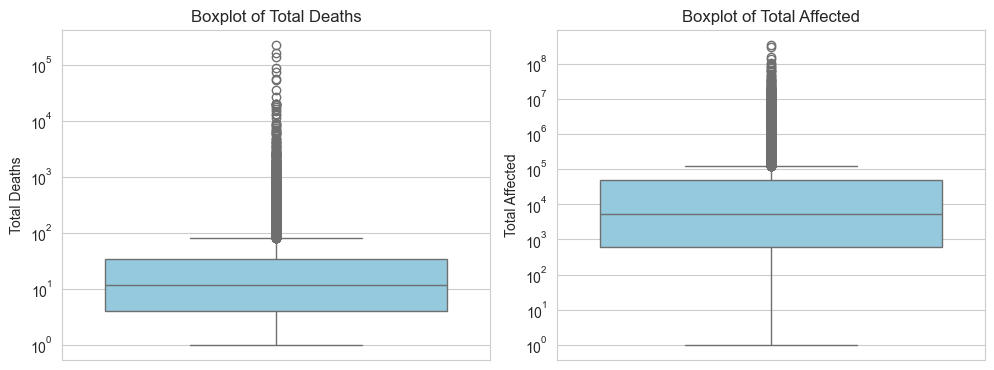

In [52]:
numerical_cols = ['Total Deaths', 'Total Affected']

# Vẽ boxplot cho từng biến số với log scale
num_plots = len(numerical_cols)
num_cols = 3
num_rows = (num_plots + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df_disaster[col].dropna(), color='skyblue')
    plt.yscale("log")   # chuyển sang log scale
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel(col)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


# 3. Tiền xử lý dữ liệu

In [53]:
df_processed = df_disaster.copy()

## 3.1. Xử lý dữ liệu bị thiếu

In [54]:
# Xử lý Total Deaths - fill bằng 0 (theo nguyên tắc của bộ dữ liệu EMDAT)
print(f"Số missing values trước khi xử lý: {df_processed['Total Deaths'].isnull().sum()}")
print(f"Tỷ lệ missing: {df_processed['Total Deaths'].isnull().sum()/len(df_processed)*100:.2f}%")

df_processed['Total Deaths'] = df_processed['Total Deaths'].fillna(0)
print(f"Số missing values sau khi xử lý: {df_processed['Total Deaths'].isnull().sum()}")


Số missing values trước khi xử lý: 2988
Tỷ lệ missing: 28.20%
Số missing values sau khi xử lý: 0


## 3.2. Chuyển đổi dữ liệu Time Series

In [55]:
df_time = df_processed.copy()

In [56]:
df_time = (df_time.groupby(['Country','Subregion', 'Start Year', 'ISO'], as_index=False)
         .agg(
             Total_Deaths=('Total Deaths', 'sum'),
         ))

In [57]:
df_time.info()

<class 'pandas.DataFrame'>
RangeIndex: 3226 entries, 0 to 3225
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       3226 non-null   str    
 1   Subregion     3226 non-null   str    
 2   Start Year    3226 non-null   int64  
 3   ISO           3226 non-null   str    
 4   Total_Deaths  3226 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 126.1 KB


In [58]:
df_time = df_time.rename(columns={'ISO': 'Country Code', 'Start Year':'Year'})
display(df_time.head())

,Country,Subregion,Year,Country Code,Total_Deaths
0,Afghanistan,Southern Asia,2000,AFG,594.0
1,Afghanistan,Southern Asia,2001,AFG,485.0
2,Afghanistan,Southern Asia,2002,AFG,4083.0
3,Afghanistan,Southern Asia,2003,AFG,137.0
4,Afghanistan,Southern Asia,2004,AFG,18.0


## 3.3. Lựa chọn khu vực và quốc gia để phân tích

In [59]:
df_time['Subregion'].unique()

<StringArray>
[                  'Southern Asia',                 'Southern Europe',
                 'Northern Africa',                       'Polynesia',
              'Sub-Saharan Africa', 'Latin America and the Caribbean',
                    'Western Asia',       'Australia and New Zealand',
                  'Western Europe',                  'Eastern Europe',
                'Northern America',              'South-eastern Asia',
                    'Eastern Asia',                 'Northern Europe',
                       'Melanesia',                      'Micronesia',
                    'Central Asia']
Length: 17, dtype: str

In [60]:
# Nhóm sẽ group các Subregion thành 7 vùng địa lý phổ biến để thực hiện nghiên cứu bao gồm: East Asia and Pacific, Europe and Central Asia, Latin America and Caribbean, Middle East and North Africa, North America, South Asia, Sub-Saharan Africa

In [61]:
# Tạo mapping từ Subregion đến Region (7 vùng lớn)
region_mapping = {
    'Eastern Asia': 'East Asia and Pacific',
    'South-eastern Asia': 'East Asia and Pacific',
    'Australia and New Zealand': 'East Asia and Pacific',
    'Melanesia': 'East Asia and Pacific',
    'Micronesia': 'East Asia and Pacific',
    'Polynesia': 'East Asia and Pacific',
    'Southern Europe': 'Europe and Central Asia',
    'Western Europe': 'Europe and Central Asia',
    'Eastern Europe': 'Europe and Central Asia',
    'Northern Europe': 'Europe and Central Asia',
    'Central Asia': 'Europe and Central Asia',
    'Latin America and the Caribbean': 'Latin America and Caribbean',
    'Northern Africa': 'Middle East and North Africa',
    'Western Asia': 'Middle East and North Africa',
    'Northern America': 'North America',
    'Southern Asia': 'South Asia',
    'Sub-Saharan Africa': 'Sub-Saharan Africa'
}

# Ánh xạ để tạo cột Region mới
df_time['Region'] = df_time['Subregion'].map(region_mapping)

# Kiểm tra nếu có giá trị Subregion không được ánh xạ (NaN) thì xử lý
if df_time['Region'].isnull().any():
    print("Warning: Some Subregions were not mapped:")
    print(df_time[df_time['Region'].isnull()]['Subregion'].unique())

In [62]:
# Để đảm bảo chất lượng dữ liệu đầu vào cho mô hình, nhóm sẽ chọn tương ứng mỗi vùng địa lý 2 quốc gia tiêu biểu có số năm có thảm hoạ thoả mãn >= 23 năm để phân tích chạy mô hình

In [63]:
# Lọc các năm từ 2000 đến 2024
df_time_filtered_years = df_time[(df_time['Year'] >= 2000) & (df_time['Year'] <= 2024)].copy()

# Đếm số năm có thảm họa của mỗi quốc gia
country_disaster_years = df_time_filtered_years.groupby('Country')['Year'].nunique().reset_index()
country_disaster_years.columns = ['Country', 'Number of Disaster Years']

# Lọc các quốc gia có số năm thảm họa >= 23
filtered_countries = country_disaster_years[country_disaster_years['Number of Disaster Years'] >= 24]

print("Các quốc gia có dữ liệu thảm họa từ 23 năm trở lên (từ 2000-2024):")
display(filtered_countries)

# Lọc df_time chỉ giữ các quốc gia đã được chọn
df_selected_countries = df_time[df_time['Country'].isin(filtered_countries['Country'])]

# Tạo DataFrame theo yêu cầu: Region, Countries và Number of Countries
df_region_selected_countries = (
    df_selected_countries.groupby('Region')
    .agg(
        Countries=('Country', lambda x: list(x.unique())),
        Num_Countries=('Country', 'nunique')
    )
    .reset_index()
)


Các quốc gia có dữ liệu thảm họa từ 23 năm trở lên (từ 2000-2024):


,Country,Number of Disaster Years
0,Afghanistan,25
7,Argentina,25
9,Australia,25
13,Bangladesh,25
21,Bolivia (Plurinational State of),24
24,Brazil,25
32,Canada,24
38,China,25
41,Colombia,25
52,Democratic Republic of the Congo,24


In [64]:
print("\nDataFrame của các Region với danh sách và số lượng quốc gia đã chọn:")
display(df_region_selected_countries)


DataFrame của các Region với danh sách và số lượng quốc gia đã chọn:


,Region,Countries,Num_Countries
0,East Asia and Pacific,"[Australia, China, Indonesia, Japan, Philippin...",8
1,Europe and Central Asia,"[France, Italy, Poland, Romania, Tajikistan, U...",6
2,Latin America and Caribbean,"[Argentina, Bolivia (Plurinational State of), ...",9
3,Middle East and North Africa,[Sudan],1
4,North America,"[Canada, United States of America]",2
5,South Asia,"[Afghanistan, Bangladesh, India, Iran (Islamic...",7
6,Sub-Saharan Africa,"[Democratic Republic of the Congo, Kenya, Mada...",8


In [65]:
# Các quốc gia được chọn:
# Viet Nam, Japan
# France, Italy
# Brazil, Mexico
# Sudan,Türkiye
# Canada,United States of America
# Indian, Pakistan
# South Africa, Kenya

## 3.4. Kết hợp dữ liệu dân số để tính toán tỷ lệ tử vong

### Xử lý dữ liệu dân số

In [66]:
# Xử lý dữ liệu dân số
print("Cấu trúc dữ liệu ban đầu:")
print(f"Số dòng: {df_population.shape[0]}, Số cột: {df_population.shape[1]}")
print(f"Các cột: {list(df_population.columns)[:10]}...")  # Hiển thị 10 cột đầu

# Tạo danh sách các cột cần giữ: Country và 2000 - 2024
years_to_keep = [str(year) for year in range(2000, 2025)]  # 2000 đến 2024
columns_to_keep = ['Country Code'] + years_to_keep

# Lọc các cột cần thiết
df_population_filtered = df_population[columns_to_keep]

print("\nSau khi lọc:")
print(f"Số dòng: {df_population_filtered.shape[0]}, Số cột: {df_population_filtered.shape[1]}")
print(f"Các cột đã giữ: {list(df_population_filtered.columns)}")

# Chuyển đổi từ wide format sang long format (melt)
df_population_long = df_population_filtered.melt(
    id_vars=['Country Code'],
    value_vars=years_to_keep,
    var_name='Year',
    value_name='Population'
)

# Sắp xếp lại dữ liệu cho dễ đọc
df_population_long = df_population_long.sort_values(['Country Code', 'Year']).reset_index(drop=True)

print(f"\n Đã chuyển đổi sang long format thành công!")
print(f"Số dòng mới: {df_population_long.shape[0]}, Số cột: {df_population_long.shape[1]}")
print(f"Các cột: {list(df_population_long.columns)}")

# Hiển thị 10 dòng đầu
print("\n10 dòng đầu tiên của dữ liệu đã chuyển đổi:")
print(df_population_long.head(10))

# Thống kê cơ bản
print("\n Thống kê cơ bản:")
print(f"Số lượng quốc gia: {df_population_long['Country Code'].nunique()}")
print(f"Số năm dữ liệu: {df_population_long['Year'].nunique()}")
print(f"Phạm vi năm: {df_population_long['Year'].min()} - {df_population_long['Year'].max()}")

# Kiểm tra dữ liệu null
missing_population = df_population_long['Population'].isnull().sum()
total_records = len(df_population_long)
print(f"Số bản ghi bị thiếu dân số: {missing_population}/{total_records} ({missing_population/total_records*100:.1f}%)")

Cấu trúc dữ liệu ban đầu:
Số dòng: 265, Số cột: 69
Các cột: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965']...

Sau khi lọc:
Số dòng: 265, Số cột: 26
Các cột đã giữ: ['Country Code', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']

 Đã chuyển đổi sang long format thành công!
Số dòng mới: 6625, Số cột: 3
Các cột: ['Country Code', 'Year', 'Population']

10 dòng đầu tiên của dữ liệu đã chuyển đổi:
  Country Code  Year  Population
0          ABW  2000       90588
1          ABW  2001       91439
2          ABW  2002       92074
3          ABW  2003       93128
4          ABW  2004       95138
5          ABW  2005       97635
6          ABW  2006       99405
7          ABW  2007      100150
8          ABW  2008      100917
9          ABW  2009      101604

 Thống kê cơ bản:

In [75]:
df_population_clean = df_population_long.copy()

In [69]:
# Chuyển đổi kiểu dữ liệu
df_population_clean['Year'] = df_population_clean['Year'].astype(int)
df_population_clean['Population'] = pd.to_numeric(df_population_clean['Population'], errors='coerce')

### Merge dữ liệu

In [70]:
# Merge dân số từ df_long vào df_time
df_merged = df_time.merge(
    df_population_clean,
    left_on=["Country Code", "Year"], # Changed to Country Code
    right_on=["Country Code", "Year"], # Changed to Country Code
    how="left"
)
print(df_merged.info())

<class 'pandas.DataFrame'>
RangeIndex: 3226 entries, 0 to 3225
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       3226 non-null   str    
 1   Subregion     3226 non-null   str    
 2   Year          3226 non-null   int64  
 3   Country Code  3226 non-null   str    
 4   Total_Deaths  3226 non-null   float64
 5   Region        3226 non-null   str    
 6   Population    3056 non-null   float64
dtypes: float64(2), int64(1), str(4)
memory usage: 176.6 KB
None


In [71]:
print(f"Số bản ghi trước khi lọc: {len(df_merged)}")
df_merged = df_merged[df_merged['Year'] <= 2024]
print(f"Số bản ghi sau khi lọc: {len(df_merged)}")
display(df_merged.head())

Số bản ghi trước khi lọc: 3226
Số bản ghi sau khi lọc: 3124


,Country,Subregion,Year,Country Code,Total_Deaths,Region,Population
0,Afghanistan,Southern Asia,2000,AFG,594.0,South Asia,20130327.0
1,Afghanistan,Southern Asia,2001,AFG,485.0,South Asia,20284307.0
2,Afghanistan,Southern Asia,2002,AFG,4083.0,South Asia,21378117.0
3,Afghanistan,Southern Asia,2003,AFG,137.0,South Asia,22733049.0
4,Afghanistan,Southern Asia,2004,AFG,18.0,South Asia,23560654.0


In [72]:
df_merged[df_merged['Population'].isnull()]['Country Code'].unique()

<StringArray>
['AIA', 'SPI', 'COK', 'GUF', 'GLP', 'MTQ', 'MYT', 'MSR', 'NIU', 'REU', 'BLM',
 'SHN', 'SCG', 'TWN', 'TKL', 'WLF']
Length: 16, dtype: str

In [73]:
print(f"Số bản ghi trước khi drop NaN ở cột Population: {len(df_merged)}")
df_merged.dropna(subset=['Population'], inplace=True)
print(f"Số bản ghi sau khi drop NaN ở cột Population: {len(df_merged)}")
display(df_merged.head())

Số bản ghi trước khi drop NaN ở cột Population: 3124
Số bản ghi sau khi drop NaN ở cột Population: 3056


,Country,Subregion,Year,Country Code,Total_Deaths,Region,Population
0,Afghanistan,Southern Asia,2000,AFG,594.0,South Asia,20130327.0
1,Afghanistan,Southern Asia,2001,AFG,485.0,South Asia,20284307.0
2,Afghanistan,Southern Asia,2002,AFG,4083.0,South Asia,21378117.0
3,Afghanistan,Southern Asia,2003,AFG,137.0,South Asia,22733049.0
4,Afghanistan,Southern Asia,2004,AFG,18.0,South Asia,23560654.0


### Tính tỷ lệ tử vong

In [74]:
# Mortality rate trên 100,000 dân
df_merged['Mortality_Rate'] = (df_merged['Total_Deaths'] / df_merged['Population']) * 100000

   # Xử lý giá trị vô hạn/NaN
df_merged['Mortality_Rate'] = df_merged['Mortality_Rate'].replace([np.inf, -np.inf], np.nan)
df_merged['Mortality_Rate'] = df_merged['Mortality_Rate'].fillna(0)

print("Thống kê Mortality Rate:")
print(df_merged['Mortality_Rate'].describe())

Thống kê Mortality Rate:
count    3056.000000
mean        2.428499
std        43.402833
min         0.000000
25%         0.014627
50%         0.098504
75%         0.444079
max      2341.549687
Name: Mortality_Rate, dtype: float64
